<a href="https://colab.research.google.com/github/ValTal5/ecg-arrhythmia-classification/blob/main/Valentino/ecg_arrhythmia_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Multi-class Classification on MIT-BIH Arrhythmia Database

**Course:** Artificial Intelligence in Medicine

**Authors:** Nicoletta Toma, Laura Tufo, Valentino Vacirca

---

## Narrative & Perspective

**Central question:** Can we build a deep learning system capable of accurately classifying heartbeat morphologies into specific clinical categories?

This is a **supervised multi-class classification** task. We aim to leverage professional cardiologist annotations to train models that recognize the specific 'signatures' of different arrhythmias.

Key challenges addressed in this project:
1. **Extreme Class Imbalance**: Some arrhythmias are thousands of times rarer than normal beats.
2. **Temporal Feature Extraction**: Capturing the intricate relationships between the P-wave, QRS complex, and T-wave.
3. **Modern Architectures**: Comparing traditional RNNs with state-of-the-art **Liquid Neural Networks (CfC)**.

---

## Model Strategy

We will explore architectures of increasing complexity to handle the sequential nature of ECG signals:

| Model | Type | Learning Paradigm |
|---|---|---|
| Random Forest | Baseline | Statistical features (Mean, Std, Skewness) |
| 1D-CNN | Deep Learning | Automated spatial feature extraction |
| Bi-LSTM | Deep Learning | Recurrent sequential dependencies |
| **Liquid NN (CfC)** | **SOTA** | **Closed-form Continuous-time neural networks** |

---

---
## 1. Setup and Data Loading

### 1.1 Dependencies

All standard scientific libraries (numpy, matplotlib, sklearn, torch) are already installed on Colab. We only need to install two additional packages:

- **`wfdb`**: official PhysioNet library for reading ECG records (`.dat` / `.hea` / `.atr` files).
- **`ncps`**: Neural Circuit Policies —> provides the **CfC (Liquid NN)** implementation.

### 1.1.1 Google Drive Mounting

In [ ]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

# Path to the dataset
DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
!pip install wfdb ncps --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


### 1.2 Imports and Global Settings

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import wfdb

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cpu


### Segmentation Logic

To transform the continuous ECG signal into a dataset suitable for classification, we apply a windowing process centered around the **R-peak** (provided by the clinical annotations):

1.  **Fixed-Width Windows**: For each annotated heartbeat, we extract a segment of signal surrounding the R-peak.
2.  **Window Parameters**: We use a `HALF_WINDOW` of 90 samples. At a sampling rate of 360 Hz, this captures 250ms before and 250ms after the peak, resulting in a total `BEAT_LEN` of 180 samples (approx. 500ms).
3.  **Signal Normalization**: Each extracted segment is typically Z-score normalized (zero mean, unit variance) to ensure that the model learns morphological patterns rather than absolute amplitude variations between different recordings.

This approach ensures that each input sample contains the full QRS complex and the immediate surrounding temporal context necessary for arrhythmia identification.

### 1.3 Download MIT-BIH from PhysioNet

The MIT-BIH Arrhythmia Database contains 48 two-channel ambulatory ECG recordings, each approximately 30 minutes long, sampled at **360 Hz**. Every beat is annotated with a symbol by trained cardiologists (e.g. `N` = normal sinus, `V` = premature ventricular contraction, `A` = atrial premature beat).

In [ ]:
import zipfile

# Path
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')
ZIP_PATH = '/content/mit-bih-arrhythmia-database-1.0.0.zip'

if not os.path.exists(DATA_DIR):
    if os.path.exists(ZIP_PATH):
        print(f"Extracting dataset from {ZIP_PATH}...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(DRIVE_PATH)

        extracted_folder = os.path.join(DRIVE_PATH, 'mit-bih-arrhythmia-database-1.0.0')
        if os.path.exists(extracted_folder):
            os.rename(extracted_folder, DATA_DIR)
        print("Extraction completed.")
    else:
        print('Downloading from PhysioNet...')
        wfdb.dl_database('mitdb', DATA_DIR)
        print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')




Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.


### 1.4 AAMI Mapping Detail

To make the results clinically relevant, we follow the **AAMI EC57** recommendation. This standard groups the original MIT-BIH symbols into 5 main categories:

| AAMI Class | Description | MIT-BIH Symbols |
|---|---|---|
| **N** (Normal) | Normal beat, Left/Right bundle branch block | `N`, `L`, `R`, `e`, `j` |
| **S** (SVEB) | Supraventricular ectopic beat | `A`, `a`, `J`, `S` |
| **V** (VEB) | Ventricular ectopic beat | `V`, `E` |
| **F** (Fusion) | Fusion of ventricular and normal beat | `F` |
| **P** (Paced) | Paced beat, fusion of paced and normal | `/`, `f` |

*Note: 'Unknown' (Q) and 'Other' symbols are typically excluded from the primary classification to maintain focus on diagnostic categories.*

In [ ]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI clinical categories."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal', # N
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',                         # S
        'V': 'VEB', 'E': 'VEB',                                                   # V
        'F': 'Fusion',                                                            # F
    }
    return mapping.get(symbol, 'Excluded')

In [ ]:
try:
    print(f"Clinical label distribution (Record 100):")
    counts = Counter([get_aami_category(s) for s in ann_symbols if get_aami_category(s) != 'Other'])
    for cat, count in counts.items():
        print(f" - {cat}: {count}")
except NameError:
    print("Note: Load a record first to see the distribution.")

Clinical label distribution (Record 100):
Note: Load a record first to see the distribution.


### 1.5 Train / Test Split: The De Chazal (2004) Standard

**Critical methodological choice: split by full records, not individual beats.**

Splitting at the beat level would allow segments from the same patient to appear in both training and testing sets, causing *data leakage*. To ensure academic rigor and comparability with state-of-the-art literature, we adopt the split proposed by **De Chazal et al. (2004)**.

This standard divides the MIT-BIH records into two independent sets (DS1 and DS2).

#### Exclusion of Paced-Dominant Records
Following this methodology, four records are explicitly excluded: **102, 104, 107, and 217**. These are omitted because they consist predominantly of paced beats, which the AAMI standard suggests evaluating separately to avoid interfering with spontaneous arrhythmia morphology.

| Set | Records (IDs) | Purpose |
|---|---|---|
| **DS1 (Train)** | 101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230 | Model training and internal validation |
| **DS2 (Test)** | 100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234 | Final independent evaluation |

By using this fixed partition, we ensure that the model is evaluated on entirely 'unseen' patients, providing a realistic estimate of its diagnostic performance in a clinical setting.

In [ ]:
### 1.5 Train / Validation / Test Split
import random

# Dataset 1 (DS1) - Usato per lo sviluppo del modello (Training e Validation)
DS1 = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124',
       '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

# Dataset 2 (DS2) - Usato ESCLUSIVAMENTE per la valutazione finale (Test)
DS2 = ['100', '103', '105', '111', '113', '117', '121', '123',
       '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

# To maintain a validation set, we take the last 3 records of DS1
TRAIN_RECORDS = DS1[:-3]
VAL_RECORDS   = DS1[-3:]
TEST_RECORDS  = DS2

print(f'Train Records (from DS1): {len(TRAIN_RECORDS)}')
print(f'Val Records   (from DS1): {len(VAL_RECORDS)}')
print(f'Test Records  (DS2):      {len(TEST_RECORDS)}')
print(f'Total: {len(TRAIN_RECORDS) + len(VAL_RECORDS) + len(TEST_RECORDS)} records used (Excluding 102, 104, 107, 217)')

Train Records (from DS1): 19
Val Records   (from DS1): 3
Test Records  (DS2):      22
Total: 44 records used (Excluding 102, 104, 107, 217)


#### *Methodological Note: Why EDA on Training Set Only?*

We perform Exploratory Data Analysis exclusively on the **training records** to prevent **data leakage**. Analyzing the distribution or properties of the test set could inadvertently influence our design choices (e.g., how we handle class imbalance or normalize signals), leading to biased evaluations. To ensure a rigorous assessment of the model's generalization capabilities, the validation and test sets must remain 'unseen' during the discovery phase.

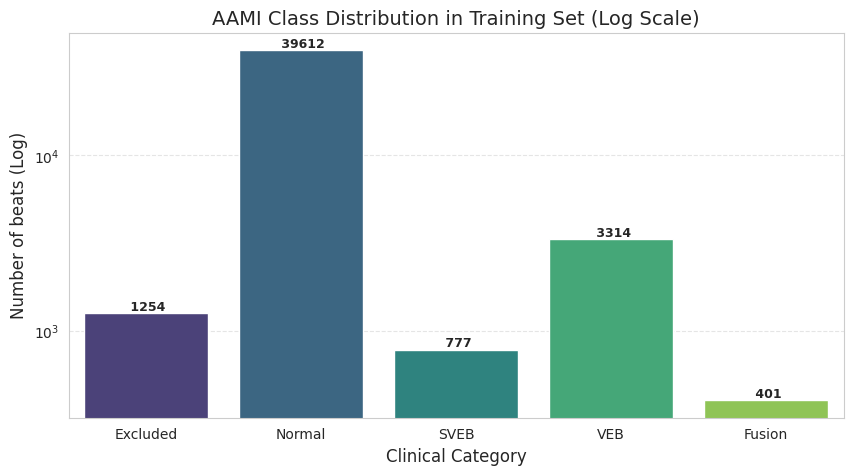

Summary statistics:
 - Excluded:   1254 beats ( 2.76%)
 - Normal  :  39612 beats (87.33%)
 - SVEB    :    777 beats ( 1.71%)
 - VEB     :   3314 beats ( 7.31%)
 - Fusion  :    401 beats ( 0.88%)


In [ ]:
# Collect all AAMI labels from training records for EDA
all_syms = []
for r in TRAIN_RECORDS:
    ann = wfdb.rdann(os.path.join(DATA_DIR, r), 'atr')
    all_syms.extend(ann.symbol)

# Filter out 'Other' to focus on AAMI classes
aami_labels = [get_aami_category(s) for s in all_syms if get_aami_category(s) != 'Other']
counts = Counter(aami_labels)

# Prepare data for Seaborn
categories = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")


ax = sns.barplot(x=categories, y=values, hue=categories, palette='viridis', legend=False)
plt.yscale('log')
plt.title('AAMI Class Distribution in Training Set (Log Scale)', fontsize=14)
plt.ylabel('Number of beats (Log)', fontsize=12)
plt.xlabel('Clinical Category', fontsize=12)

# Add absolute counts on top of bars for clarity
for i, v in enumerate(values):
    ax.text(i, v, f' {v}', ha='center', va='bottom', fontsize=9, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Summary statistics:")
for cls, count in counts.items():
    perc = (count / len(aami_labels)) * 100
    print(f" - {cls:8}: {count:6} beats ({perc:5.2f}%)")

### 1.6 Quick Record Analysis

Let's visualize 10 seconds of raw signal from record 100. Annotations indicate the beat type according to the AAMI standard (e.g., 'N' for Normal, 'V' for VEB).

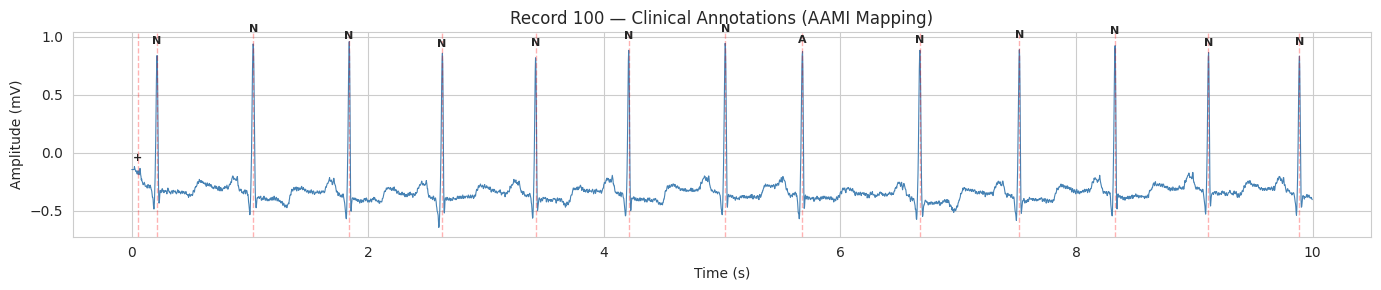

In [ ]:
record     = wfdb.rdrecord(os.path.join(DATA_DIR, '100'))
annotation = wfdb.rdann(os.path.join(DATA_DIR, '100'), 'atr')

signal      = record.p_signal[:, 0]
ann_samples = annotation.sample
ann_symbols = np.array(annotation.symbol)

n_samples = 10 * FS
t         = np.arange(n_samples) / FS
mask      = ann_samples < n_samples

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, signal[:n_samples], color='steelblue', lw=0.8, label='ECG signal')

for s, sym in zip(ann_samples[mask], ann_symbols[mask]):
    cat = get_aami_category(sym)
    if cat != 'Other':
        ax.axvline(s / FS, color='red', alpha=0.3, lw=1, linestyle='--')
        ax.text(s / FS, signal[s] + 0.1, sym, fontsize=8, weight='bold', ha='center')

ax.set(xlabel='Time (s)', ylabel='Amplitude (mV)',
       title='Record 100 — Clinical Annotations (AAMI Mapping)')
plt.tight_layout()
plt.show()

### 2.1 Beat Extraction and Processing

We define a function `load_records_filtered` that iterates through the MIT-BIH records and performs the following for each:

1. **Frequency Filtering**: Applies a Butterworth band-pass filter (0.5 – 45 Hz) to the entire signal to remove baseline wander and high-frequency noise.
2. **Peak-Centered Windowing**: For every annotated beat, it crops a segment of 180 samples (approx. 500ms) centered on the R-peak.
3. **Z-score Normalization**: Subtracts the mean and divides by the standard deviation of the individual segment to remove scale variations.
4. **Label Filtering**: Only keeps beats belonging to the 5 valid AAMI classes (Normal, SVEB, VEB, Fusion, Paced).

In [ ]:
from scipy.signal import butter, filtfilt, welch
import numpy as np
import os
import wfdb

def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# --- NUOVA FUNZIONE: Estrazione Feature in Frequenza ---
def extract_frequency_features(segment, fs=360):
    # Calcolo della Power Spectral Density (PSD) con metodo di Welch
    freqs, psd = welch(segment, fs=fs, nperseg=len(segment))

    # 1. Centroide Spettrale
    spectral_centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-8)

    # 2. Potenza nelle bande cliniche (Bassa: 1-10 Hz, Alta: 10-30 Hz)
    idx_low = np.where((freqs >= 1) & (freqs <= 10))[0]
    idx_high = np.where((freqs >= 10) & (freqs <= 30))[0]

    power_low = np.sum(psd[idx_low])
    power_high = np.sum(psd[idx_high])

    # 3. Rapporto di potenza (LF/HF Ratio)
    power_ratio = power_low / (power_high + 1e-8)

    # 4. Frequenza Dominante
    dominant_freq = freqs[np.argmax(psd)]

    return [spectral_centroid, power_low, power_high, power_ratio, dominant_freq]
# -------------------------------------------------------


def load_records_filtered_and_rr(record_list, is_train=False):
    x_data = []
    rr_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3}

    # Moltiplicatori per la Data Augmentation
    augmentation_map = {0: 0, 1: 5, 2: 2, 3: 15}

    # Pool di shift validi: creiamo l'array saltando matematicamente lo 0
    valid_shifts = np.concatenate((np.arange(-12, 0), np.arange(1, 13)))

    for record_id in record_list:
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        # Calcolo del battito medio (RR) globale del paziente in secondi
        if len(peaks) > 1:
            mean_rr_patient = np.mean(np.diff(peaks)) / FS
        else:
            mean_rr_patient = 0.8 # Valore di default (circa 75 bpm) per tracciati anomali

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])

            if category in label_map:
                label_idx = label_map[category]

                # --- 1. CALCOLO INTERVALLI RR ASSOLUTI (in campioni) ---
                rr_pre = peaks[i] - peaks[i-1] if i > 0 else peaks[i+1] - peaks[i]
                rr_post = peaks[i+1] - peaks[i] if i < len(peaks)-1 else peaks[i] - peaks[i-1]

                # Convertiamo in secondi
                rr_pre_sec = rr_pre / FS
                rr_post_sec = rr_post / FS

                # --- 2. CALCOLO FEATURE RELATIVE (Rapporti) ---
                rr_ratio_local = rr_pre_sec / rr_post_sec if rr_post_sec > 0 else 1.0
                rr_ratio_global = rr_pre_sec / mean_rr_patient if mean_rr_patient > 0 else 1.0

                # Ora rr_features è un vettore di 4 dimensioni
                rr_features = [rr_pre_sec, rr_post_sec, rr_ratio_local, rr_ratio_global]

                segments_to_extract = []

                # Finestra standard centrata
                start_std = peaks[i] - HALF_WINDOW
                end_std = peaks[i] + HALF_WINDOW
                if start_std > 0 and end_std < len(signal):
                    segments_to_extract.append((start_std, end_std))

                # --- 3. DATA AUGMENTATION (JITTERING) ---
                if is_train and label_idx in augmentation_map:
                    num_shifts = augmentation_map[label_idx]
                    if num_shifts > 0:
                        shifts = np.random.choice(valid_shifts, num_shifts, replace=False)
                        for shift in shifts:
                            start_shift = (peaks[i] + shift) - HALF_WINDOW
                            end_shift = (peaks[i] + shift) + HALF_WINDOW
                            if start_shift > 0 and end_shift < len(signal):
                                segments_to_extract.append((start_shift, end_shift))

                # --- 4. ESTRAZIONE E SALVATAGGIO ---
                for start, end in segments_to_extract:
                    segment = signal[start:end]

                    # Z-score Normalization
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                    # --- NOVITÀ: ESTRAZIONE FREQUENZE E FUSIONE ---
                    # Calcoliamo le 5 feature spettrali per questo specifico segmento
                    freq_feats = extract_frequency_features(segment, fs=FS)

                    # Uniamo la lista di 4 RR feature con la lista di 5 Freq feature = 9 feature
                    combined_features = rr_features + freq_feats
                    # ----------------------------------------------

                    x_data.append(segment)
                    rr_data.append(combined_features)  # Usiamo il vettore combinato da 9 feature
                    y_data.append(label_idx)

    return np.array(x_data), np.array(rr_data), np.array(y_data)


### 2.2 Dataset Creation

Now, we apply the processing function to our split records (Train, Validation, and Test). This step may take a few moments as it processes thousands of heartbeats.

In [ ]:
print("Estrazione Training Set (Filtrato + Augmentation + RR)...")
# Nota il parametro is_train=True
X_train, X_train_rr, y_train_raw = load_records_filtered_and_rr(TRAIN_RECORDS, is_train=True)

print("Estrazione Validation Set (Filtrato + RR | NO Augmentation)...")
X_val, X_val_rr, y_val_raw = load_records_filtered_and_rr(VAL_RECORDS, is_train=False)

print("Estrazione Test Set (Filtrato + RR | NO Augmentation)...")
X_test, X_test_rr, y_test_raw = load_records_filtered_and_rr(TEST_RECORDS, is_train=False)

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")
# Stampa di verifica
print_clean_dist(y_train_raw, "Train (Dopo Augmentation)")
# Mapping for readable output

print_clean_dist(y_train_raw, "Train")
print_clean_dist(y_val_raw, "Validation")
print_clean_dist(y_test_raw, "Test")

# Keep as numpy arrays for the models
y_train, y_val, y_test = y_train_raw, y_val_raw, y_test_raw

Estrazione Training Set (Filtrato + Augmentation + RR)...
Estrazione Validation Set (Filtrato + RR | NO Augmentation)...
Estrazione Test Set (Filtrato + RR | NO Augmentation)...

Train (Dopo Augmentation) Distribution:
 - Normal (N): 39604
 - SVEB (S): 4662
 - VEB (V): 9942
 - Fusion (F): 6400

Train Distribution:
 - Normal (N): 39604
 - SVEB (S): 4662
 - VEB (V): 9942
 - Fusion (F): 6400

Validation Distribution:
 - Normal (N): 6252
 - SVEB (S): 167
 - VEB (V): 474
 - Fusion (F): 14

Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388


In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss function to down-weight easy examples and force gradients onto hard minority classes."""
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        logpt = self.ce(inputs, targets)
        pt = torch.exp(-logpt)
        # Apply scaling factor (1 - pt)^gamma to focus heavily on hard/wrong predictions
        focal_loss = ((1 - pt) ** self.gamma) * logpt
        return focal_loss.mean()

In [ ]:
from tqdm.auto import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        # Added tqdm progress bar for the training loop
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for X_batch, y_batch in train_pbar:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': loss.item()})

        # Validation
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        f1 = f1_score(all_labels, all_preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(f1)

        print(f"Epoch [{epoch+1}/{epochs}] Summary - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}")

    return history

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNFeatureExtractor(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNFeatureExtractor, self).__init__()

        # Pipeline 1D-CNN originale
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # --- MODULO DI ATTENTION SPAZIALE (TEMPORALE) ---
        # Convoluzione 1x1 per collassare i 64 canali e generare 1 singolo score per ogni timestep
        self.attention_conv = nn.Conv1d(in_channels=64, out_channels=1, kernel_size=1)

        # Layer per comprimere le feature spaziali pesate in un vettore denso da 64
        self.fc_features = nn.Linear(64 * 45, 64)

        # Classificatore temporaneo (usato SOLO per il pre-addestramento)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x, return_features=False):
        # Estrazione feature convoluzionali standard
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # Shape: [Batch, 64, 45]

        # --- CALCOLO E APPLICAZIONE DELL'ATTENTION ---
        # 1. Generazione degli score per ogni timestep
        attn_scores = self.attention_conv(x) # Shape: [Batch, 1, 45]

        # 2. Normalizzazione tramite Softmax lungo la dimensione spaziale (dim=2 corrisponde ai 45 timestep)
        attn_weights = F.softmax(attn_scores, dim=2)

        # 3. Ponderazione dinamica del tensore originale (Broadcasting lungo i 64 canali)
        x_attended = x * attn_weights
        # ---------------------------------------------

        # Appiattiamo il tensore ponderato per il layer fully connected
        x_flat = x_attended.view(x_attended.size(0), -1)

        # Estrazione delle 64 FEATURE MORFOLOGICHE finali
        features = F.relu(self.fc_features(x_flat))

        if return_features:
            return features

        out = self.dropout(features)
        return self.classifier(out)


In [ ]:
# 1. Preparazione dei tensori con la giusta dimensione per la CNN (Batch, Channels, Length)
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
y_val_t = torch.LongTensor(y_val)

# 2. Creazione dei DataLoader
BATCH_SIZE = 128
cnn_train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
cnn_val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

# 3. Inizializzazione Rete, Loss e Ottimizzatore
cnn_model = CNNFeatureExtractor(num_classes=4).to(DEVICE)
criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# 4. Lancio del PRE-ADDESTRAMENTO
print("Avvio il pre-addestramento della CNN per sbloccare lo spazio delle feature...")
training_history = train_model(
    model=cnn_model,
    train_loader=cnn_train_loader,
    val_loader=cnn_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=12  # 10-15 epoche sono sufficienti per imparare le forme d'onda
)

Avvio il pre-addestramento della CNN per sbloccare lo spazio delle feature...


Epoch 1/12 [Train]:   0%|          | 0/474 [00:00<?, ?it/s]

Epoch [1/12] Summary - Train Loss: 0.1520 | Val Loss: 0.0921 | Val F1: 0.3923


Epoch 2/12 [Train]:   0%|          | 0/474 [00:00<?, ?it/s]

Epoch [2/12] Summary - Train Loss: 0.0775 | Val Loss: 0.1127 | Val F1: 0.4370


...

Epoch [10/12] Summary - Train Loss: 0.0195 | Val Loss: 0.0884 | Val F1: 0.5199


Epoch 11/12 [Train]:   0%|          | 0/474 [00:00<?, ?it/s]

Epoch [11/12] Summary - Train Loss: 0.0180 | Val Loss: 0.1541 | Val F1: 0.4703


Epoch 12/12 [Train]:   0%|          | 0/474 [00:00<?, ?it/s]

Epoch [12/12] Summary - Train Loss: 0.0177 | Val Loss: 0.2289 | Val F1: 0.4673


In [ ]:
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

def extract_features(model, X_raw, X_rr, batch_size=256):
    """Estrae le feature dalla CNN e le concatena con gli intervalli RR."""
    model.eval()

    # Prepariamo il DataLoader per il segnale grezzo
    X_t = torch.FloatTensor(X_raw).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)

    cnn_features_list = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(DEVICE)
            # Estraiamo il vettore denso usando il flag
            features = model(inputs, return_features=True)
            cnn_features_list.append(features.cpu().numpy())

    # Combiniamo i batch in un unico array NumPy (Shape: [N, 64])
    F_cnn = np.vstack(cnn_features_list)

    # FUSIONE: Concateniamo Orizzontalmente le 64 feature CNN con le 4 feature RR
    # Risultato: Tabella finale con 68 colonne (Shape: [N, 68])
    X_fused = np.hstack((F_cnn, X_rr))

    return X_fused

print("Estrazione delle feature profonde in corso...")
X_train_fused = extract_features(cnn_model, X_train, X_train_rr)
X_val_fused   = extract_features(cnn_model, X_val, X_val_rr)
X_test_fused  = extract_features(cnn_model, X_test, X_test_rr)
print(f"Shape finale per XGBoost: {X_train_fused.shape}")

Estrazione delle feature profonde in corso...
Shape finale per XGBoost: (60608, 73)


In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# FASE 1: PREPARAZIONE DELLE MACRO-CLASSI
# ==========================================
def create_macro_labels(y):
    # 0 = QRS Stretto (N, S) | 1 = QRS Largo (V, F)
    y_macro = np.zeros_like(y)
    y_macro[(y == 2) | (y == 3)] = 1
    return y_macro

y_train_macro = create_macro_labels(y_train)
y_val_macro = create_macro_labels(y_val)


# ==========================================
# FASE 2: ADDESTRAMENTO DEI 3 ESPERTI
# ==========================================

# --- ESPERTO 1: Filtro QRS Stretto vs Largo ---
print("--- Addestramento Livello 1 (QRS Stretto vs Largo) ---")
weights_l1 = compute_sample_weight(class_weight='balanced', y=y_train_macro)
model_l1 = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    tree_method='hist', device='cuda', random_state=SEED
)
model_l1.fit(X_train_fused, y_train_macro, sample_weight=weights_l1, verbose=False)


# --- ESPERTO 2A: Classificatore Normal vs SVEB ---
print("--- Addestramento Livello 2A (Normal vs SVEB) ---")
mask_ns_train = (y_train == 0) | (y_train == 1)
X_train_ns, y_train_ns = X_train_fused[mask_ns_train], y_train[mask_ns_train]

# Manteniamo il bilanciamento automatico che aveva portato la F1 al 34%
weights_ns = compute_sample_weight(class_weight='balanced', y=y_train_ns)
model_ns = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    tree_method='hist', device='cuda', random_state=SEED
)
model_ns.fit(X_train_ns, y_train_ns, sample_weight=weights_ns, verbose=False)


# --- ESPERTO 2B: Classificatore VEB vs Fusion ---
print("--- Addestramento Livello 2B (VEB vs Fusion) CON PESI MANUALI ---")
mask_vf_train = (y_train == 2) | (y_train == 3)
X_train_vf, y_train_vf = X_train_fused[mask_vf_train], y_train[mask_vf_train]

# Mappiamo in binario: VEB(2)->0, Fusion(3)->1
y_train_vf_bin = np.where(y_train_vf == 2, 0, 1)

# TUNING MANUALE DEI PESI:
# Calcoliamo i pesi standard bilanciati...
base_weights = compute_sample_weight(class_weight='balanced', y=y_train_vf_bin)

# ...e ammorbidiamo la penalità per la classe Fusion (etichetta 1) moltiplicando per 0.5
# Questo bilancia l'effetto della Data Augmentation (x15) fatta precedentemente.
custom_weights_vf = np.where(y_train_vf_bin == 1, base_weights * 0.5, base_weights)

model_vf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    tree_method='hist', device='cuda', random_state=SEED
)
model_vf.fit(X_train_vf, y_train_vf_bin, sample_weight=custom_weights_vf, verbose=False)


# ==========================================
# FASE 3: INFERENZA A CASCATA SUL TEST SET
# ==========================================
print("\n--- Valutazione sul Test Set (DS2) Pazienti Mai Visti ---")
y_pred_final = np.zeros(len(X_test_fused))

# 1. Il Livello 1 effettua la biforcazione iniziale
preds_l1 = model_l1.predict(X_test_fused)

idx_ns = np.where(preds_l1 == 0)[0]
idx_vf = np.where(preds_l1 == 1)[0]

# 2. L'esperto N/S interviene sui QRS Stretti
if len(idx_ns) > 0:
    y_pred_final[idx_ns] = model_ns.predict(X_test_fused[idx_ns])

# 3. L'esperto V/F interviene sui QRS Larghi
if len(idx_vf) > 0:
    preds_vf_bin = model_vf.predict(X_test_fused[idx_vf])
    y_pred_final[idx_vf] = np.where(preds_vf_bin == 0, 2, 3)

# --- REPORT FINALE ---
target_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)']
print(classification_report(y_test, y_pred_final, target_names=target_names))


--- Addestramento Livello 1 (QRS Stretto vs Largo) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:36] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:36] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


--- Addestramento Livello 2A (Normal vs SVEB) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:42] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:42] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


--- Addestramento Livello 2B (VEB vs Fusion) CON PESI MANUALI ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:46] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:46] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)



--- Valutazione sul Test Set (DS2) Pazienti Mai Visti ---
              precision    recall  f1-score   support

  Normal (N)       0.95      0.90      0.93     44246
    SVEB (S)       0.34      0.17      0.23      1837
     VEB (V)       0.78      0.93      0.85      3220
  Fusion (F)       0.00      0.01      0.00       388

    accuracy                           0.87     49691
   macro avg       0.52      0.50      0.50     49691
weighted avg       0.91      0.87      0.89     49691



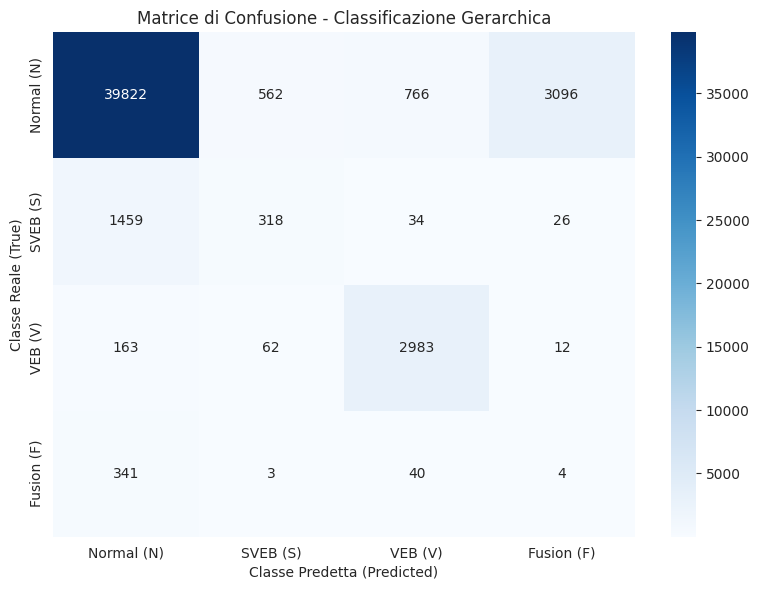

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcoliamo la matrice
cm = confusion_matrix(y_test, y_pred_final)

# Plot della matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)

plt.title('Matrice di Confusione - Classificazione Gerarchica')
plt.ylabel('Classe Reale (True)')
plt.xlabel('Classe Predetta (Predicted)')
plt.tight_layout()
plt.show()

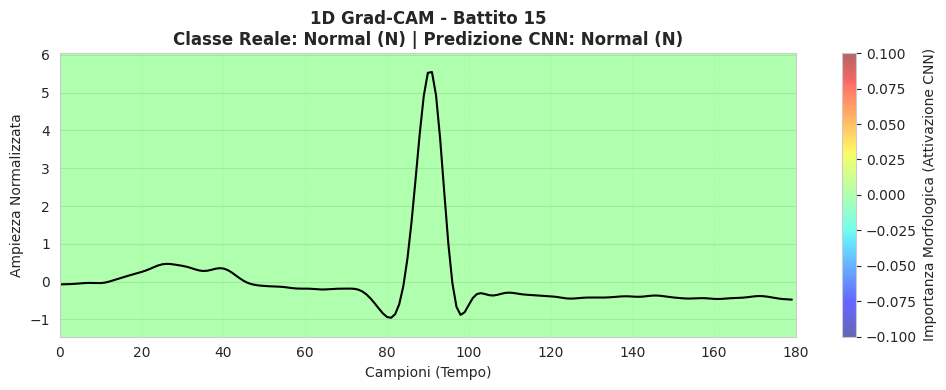

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def plot_gradcam_1d(model, X_test_raw, y_test_raw, target_idx=0):
    """
    Genera e plotta la Grad-CAM 1D per un battito ECG specifico.
    """
    # 1. Prepariamo il modello e il segnale
    model.eval()
    ecg_signal = X_test_raw[target_idx]
    true_label = y_test_raw[target_idx]

    # Shape per PyTorch: [Batch=1, Channels=1, Length=180]
    input_tensor = torch.FloatTensor(ecg_signal).unsqueeze(0).unsqueeze(0).to(DEVICE)
    input_tensor.requires_grad = True

    # Variabili per salvare le attivazioni e i gradienti
    activations = {}
    gradients = {}

    # Funzioni "Hook" per catturare i dati dall'ultimo layer convoluzionale (conv2)
    def forward_hook(module, input, output):
        activations['value'] = output

    def backward_hook(module, grad_input, grad_output):
        gradients['value'] = grad_output[0]

    # Attacchiamo gli hook al livello desiderato
    hook_f = model.conv2.register_forward_hook(forward_hook)
    hook_b = model.conv2.register_full_backward_hook(backward_hook)

    # 2. Forward Pass (Usiamo il classificatore temporaneo della CNN)
    output = model(input_tensor, return_features=False)
    pred_class = output.argmax(dim=1).item()

    # 3. Backward Pass (Calcolo dei gradienti per la classe predetta)
    model.zero_grad()
    output[0, pred_class].backward()

    # Rimuoviamo gli hook per pulizia
    hook_f.remove()
    hook_b.remove()

    # 4. Calcolo della Grad-CAM
    # Media globale dei gradienti per ogni canale
    pooled_gradients = torch.mean(gradients['value'], dim=[0, 2])

    # Moltiplichiamo le attivazioni per i gradienti pesati
    for i in range(activations['value'].shape[1]):
        activations['value'][:, i, :] *= pooled_gradients[i]

    # Media lungo i canali e applicazione della ReLU (per tenere solo le influenze positive)
    heatmap = torch.mean(activations['value'], dim=1).squeeze()
    heatmap = F.relu(heatmap)

    # Normalizzazione tra 0 e 1
    if torch.max(heatmap) > 0:
        heatmap /= torch.max(heatmap)

    # 5. Ridimensionamento (Interpolazione) per riportare la heatmap a 180 campioni
    heatmap = heatmap.unsqueeze(0).unsqueeze(0)
    heatmap_resized = F.interpolate(heatmap, size=180, mode='linear', align_corners=False)
    heatmap_resized = heatmap_resized.squeeze().cpu().detach().numpy()

    # 6. Plot del Risultato
    target_names = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

    fig, ax = plt.subplots(figsize=(10, 4))

    # Disegniamo il segnale ECG nero sovrapposto
    ax.plot(ecg_signal, color='black', linewidth=1.5, zorder=2)

    # Sovrapponiamo la mappa di calore (Heatmap)
    extent = [0, 180, min(ecg_signal)-0.5, max(ecg_signal)+0.5]
    im = ax.imshow(heatmap_resized[np.newaxis, :], cmap='jet', aspect='auto',
                   alpha=0.6, extent=extent, zorder=1)

    plt.colorbar(im, label='Importanza Morfologica (Attivazione CNN)')

    title = f'1D Grad-CAM - Battito {target_idx}\nClasse Reale: {target_names.get(true_label, "Altro")} | Predizione CNN: {target_names.get(pred_class, "Altro")}'
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Campioni (Tempo)', fontsize=10)
    plt.ylabel('Ampiezza Normalizzata', fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ESEMPIO DI UTILIZZO:
# Cambia l'indice per vedere battiti diversi (es. trova un indice che corrisponde a una VEB nel test set)
plot_gradcam_1d(cnn_model, X_test, y_test, target_idx=15)